<a href="https://colab.research.google.com/github/ARehman007-max/internship/blob/main/task12_Building_Models_with_TensorFlow_Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 387 (1.51 KB)

 Trainable params: 387 (1.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.2124 - loss: 1.2592 - val_accuracy: 0.4828 - val_loss: 0.8511
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2124 - loss: 1.1428 - val_accuracy: 0.4828 - val_loss: 0.7874
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.2124 - loss: 1.0616 - val_accuracy: 0.4828 - val_loss: 0.7355
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2566 - loss: 0.9969 - val_accuracy: 0.5172 - val_loss: 0.6954
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3451 - loss: 0.9502 - val_accuracy: 0.5862 - val_loss: 0.6632
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4779 - loss: 0.9090 - val_accuracy: 0.6897 - val_loss: 0.6342
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5929 - loss: 0.8719 - val_accuracy: 0.7241 - val_loss: 0.6005
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7788 - loss: 0.8342 - val_accuracy: 0.8276 - v

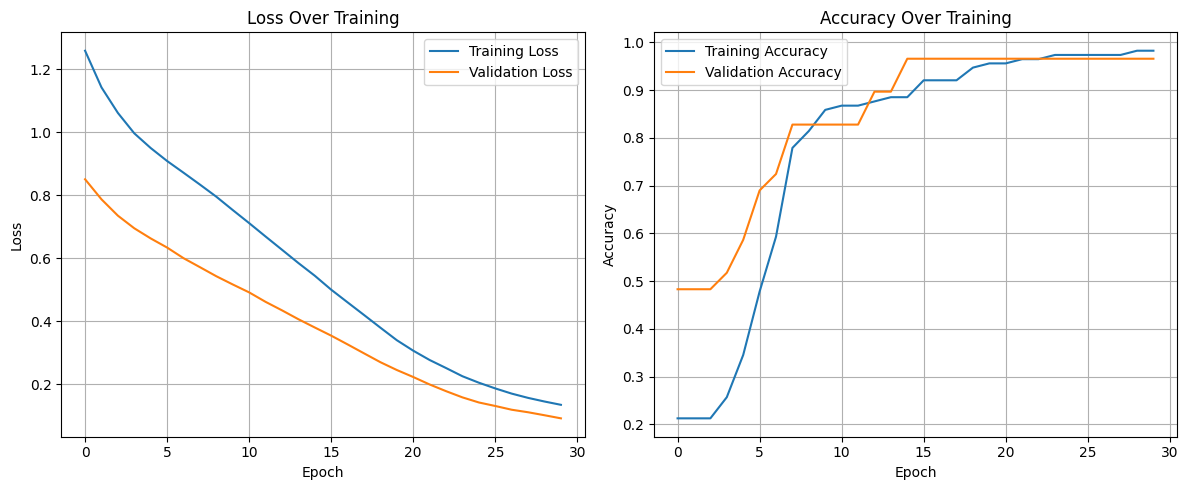

Test accuracy: 0.9444
Test loss: 0.1649
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

Predictions vs Actual:
Sample 1: Predicted = 0, Actual = 0
Sample 2: Predicted = 1, Actual = 2
Sample 3: Predicted = 0, Actual = 0
Sample 4: Predicted = 2, Actual = 1
Sample 5: Predicted = 1, Actual = 1
Sample 6: Predicted = 0, Actual = 0
Sample 7: Predicted = 0, Actual = 0
Sample 8: Predicted = 1, Actual = 1
Sample 9: Predicted = 1, Actual = 1
Sample 10: Predicted = 2, Actual = 2

Correct predictions: 34/36 (94.44%)

Model saved as 'wine_classifier.keras'
Loaded model accuracy: 0.9444


In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers

# 1. Load and prepare the data
wine = load_wine()
X = wine.data
y = wine.target

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale the features (important for neural networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Build the model using Sequential API
model = keras.Sequential([
    layers.Input(shape=(13,)),              # 13 input features
    layers.Dense(16, activation="relu"),    # hidden layer 1
    layers.Dense(8, activation="relu"),     # hidden layer 2
    layers.Dense(3, activation="softmax")   # output layer (3 classes)
])

# Display model architecture
model.summary()

# 3. Compile the model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 4. Train the model
history = model.fit(
    X_train_scaled, y_train,
    epochs=30,
    batch_size=8,
    validation_split=0.2,
    verbose=1
)

# 5. Visualize training history
plt.figure(figsize=(12, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Over Training")
plt.legend()
plt.grid(True)

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Over Training")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 6. Evaluate on test data
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test loss: {test_loss:.4f}")

# 7. Make predictions
predictions = model.predict(X_test_scaled)
predicted_classes = predictions.argmax(axis=1)

# Compare predictions with actual values
print("\nPredictions vs Actual:")
for i in range(min(10, len(predicted_classes))):
    print(f"Sample {i+1}: Predicted = {predicted_classes[i]}, Actual = {y_test[i]}")

# Calculate and display classification results
correct = np.sum(predicted_classes == y_test)
total = len(y_test)
print(f"\nCorrect predictions: {correct}/{total} ({100*correct/total:.2f}%)")

# 8. Save the model for future use
model.save("wine_classifier.keras")
print(f"\nModel saved as 'wine_classifier.keras'")

# 9. Demonstrate loading the model
loaded_model = keras.models.load_model("wine_classifier.keras")
loaded_loss, loaded_accuracy = loaded_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Loaded model accuracy: {loaded_accuracy:.4f}")

In [2]:
# Build the same model using Functional API
inputs = keras.Input(shape=(13,))
x = layers.Dense(16, activation="relu")(inputs)
x = layers.Dense(8, activation="relu")(x)
outputs = layers.Dense(3, activation="softmax")(x)

functional_model = keras.Model(inputs=inputs, outputs=outputs)
functional_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

functional_model.fit(
    X_train_scaled, y_train,
    epochs=30,
    batch_size=8,
    validation_split=0.2,
    verbose=0
)

functional_loss, functional_accuracy = functional_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Functional model accuracy: {functional_accuracy:.4f}")

Functional model accuracy: 1.0000
